## Main code

In [1]:
! # Make sure to enable the ipycanvas/ other widgets
!jupyter labextension enable widgetsnbextension

In [364]:
import pandas as pd
import numpy as np
import anndata as ad
import scanpy as sc
import squidpy as sq

from popari.io import save_anndata, load_anndata

from popari.simulation_framework import MultiReplicateSyntheticDataset, SyntheticDataset, SimulationParameters

from pathlib import Path

import matplotlib.pyplot as plt
import random
import seaborn as sns

In [365]:
from importlib import reload
from popari import simulation_framework
reload(simulation_framework)
from popari.simulation_framework import MultiReplicateSyntheticDataset, SyntheticDataset, SimulationParameters

In [366]:
from popari.io import save_anndata, load_anndata
from popari.components import PopariDataset
from popari._dataset_utils import _plot_all_embeddings, _plot_in_situ, _multireplicate_heatmap, _compute_empirical_correlations

In [367]:
cell_type_definitions = {
    "Excitatory L1":         [0.5, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0],
    "Excitatory L2":         [0.5, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0],
    "Excitatory L3":         [0.5, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0],
    "Excitatory L4":         [0.5, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1],
    "Inhibitory L1":         [0, 0.5, 0, 1, 0, 0, 0, 0, 0, 0, 0],
    "Inhibitory L2":         [0, 0.5, 0, 0, 1, 0, 0, 0, 0, 0, 0],
    "Inhibitory L3":         [0, 0.5, 0, 0, 0, 1, 0, 0, 0, 0, 0],
    "Inhibitory L4":         [0, 0.5, 0, 0, 0, 0, 1, 0, 0, 0, 0],
    "Non-Neuron Ubiquitous": [0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0],
}
progenitor_distributions = {
    "L1": {
        "Excitatory L1": 0.53,
        "Inhibitory L1": 0.2,
        "Inhibitory L2": 0.2,
        "Non-Neuron Ubiquitous": 0.07,
    },
    "L2": {
        "Excitatory L2": 0.53,
        "Inhibitory L2": 0.2,
        "Inhibitory L3": 0.2,
        "Non-Neuron Ubiquitous": 0.07,
    },
    "L3": {
        "Excitatory L3": 0.53,
        "Inhibitory L3": 0.2,
        "Inhibitory L4": 0.2,
        "Non-Neuron Ubiquitous": 0.07,
    },
    "L4": {
        "Excitatory L4": 0.53,
        "Inhibitory L3": 0.2,
        "Inhibitory L4": 0.2,
        "Non-Neuron Ubiquitous": 0.07,
    },
}

layer_distributions = {
    "L1": {
        "Excitatory L1": 0.2,
        "Excitatory L2": 0.2,
        "Inhibitory L1": 0.53,
        "Non-Neuron Ubiquitous": 0.07,
    },
    "L2": {
        "Excitatory L2": 0.2,
        "Excitatory L3": 0.2,
        "Inhibitory L2": 0.53,
        "Non-Neuron Ubiquitous": 0.07,
    },
    "L3": {
        "Excitatory L3": 0.2,
        "Excitatory L4": 0.2,
        "Inhibitory L3": 0.53,
        "Non-Neuron Ubiquitous": 0.07,
    },
    "L4": {
        "Excitatory L3": 0.2,
        "Excitatory L4": 0.2,
        "Inhibitory L4": 0.53,
        "Non-Neuron Ubiquitous": 0.07,
    },
}

metagene_variation_probabilities = [0, 0.1, 0, 0, 0.1, 0.1, 0.1, 0, 0.1, 0.1, 0.1]

shared_parameters = {
    'num_genes': 100,
    'annotation_mode': 'domain',
    'num_real_metagenes': 11,
    'num_noise_metagenes': 0,
    'sig_y_scale': 1.0,
    'sig_x_scale': 1.0,
    'real_metagene_parameter': 8.0,
    'noise_metagene_parameter': 4.0,
    'lambda_s': 1.,
    'width': 1,
    'height': 1,
    'grid_size': 15,
    'metagene_variation_probabilities': metagene_variation_probabilities,
    'cell_type_definitions': cell_type_definitions,
    'domain_key': 'domain',
}

progenitor_parameters = SimulationParameters(
    **shared_parameters,
    spatial_distributions=progenitor_distributions,
)

layer_parameters = SimulationParameters(
    **shared_parameters,
    spatial_distributions=layer_distributions,
)

num_copies = 5
duplicated_parameters = [
    {
        f"progenitor_{index}": progenitor_parameters,
        f"layer_{index}": layer_parameters,
    }
    for index in range(num_copies)
]
replicate_parameters = {replicate_name: parameters for replicate_parameters in duplicated_parameters for replicate_name, parameters in replicate_parameters.items()}



In [371]:
multireplicate_dataset = MultiReplicateSyntheticDataset(replicate_parameters, SyntheticDataset, random_state=101, verbose=0, percent_batch_effect=0.3)

In [375]:
multireplicate_dataset.annotate_replicate_domain("layer_0")

Annotating replicate layer_0


Choose a domain to annotate (enter an integer):
0: L1
1: L2
2: L3
3: L4
 3


Output()

Canvas(height=600, image_data=b'\x89PNG\r\n\x1a\n\x00\x00\x00\rIHDR\x00\x00\x02X\x00\x00\x02X\x08\x06\x00\x00\…

Canvas(height=600, image_data=b'\x89PNG\r\n\x1a\n\x00\x00\x00\rIHDR\x00\x00\x02X\x00\x00\x02X\x08\x06\x00\x00\…

In [376]:
layer_domains = multireplicate_dataset.datasets["layer_0"].domain_canvas.domains

for i in range(5):
   multireplicate_dataset.datasets[f"progenitor_{i}"].domain_canvas.load_domains(layer_domains)
   multireplicate_dataset.datasets[f"layer_{i}"].domain_canvas.load_domains(layer_domains) 

In [377]:
multireplicate_dataset.assign_domain_labels()

In [378]:
# # Same parameters for each replicate (for now)
# replicate_simulation_parameters = {}
# for i in range(5):
#     replicate_simulation_parameters.update({
#         f"progenitor_{i}": simulation_parameters,
#         f"layer_{i}": simulation_parameters
#     })

multireplicate_dataset.simulate_expression()

In [379]:
for dataset in multireplicate_dataset:
    print("batch_effect", dataset.uns["batch_effect"][dataset.name])
    print("ground truth", dataset.obsm["ground_truth_X"][0])

batch_effect [0.         0.         4.67985747 0.         0.         0.
 0.         9.62983264 0.         8.41462837 0.        ]
ground truth [ 0.          0.         18.84283101  0.          0.          0.
  0.          9.62983264  0.          8.41462837  0.        ]
batch_effect [0.         0.         0.         0.43820758 0.         0.
 8.83688155 7.62711151 0.         0.         0.        ]
ground truth [ 3.97372693  0.          0.          0.43820758  0.          0.
  8.83688155 22.02981686  0.          0.          0.        ]
batch_effect [0.         0.         0.         7.23880584 0.         0.
 0.         0.         1.43248977 3.45735044 0.        ]
ground truth [3.48665124 0.         0.         7.23880584 0.         0.
 0.         7.22857295 1.43248977 3.45735044 0.        ]
batch_effect [2.38308907 0.         0.         0.06407596 0.         0.
 0.         0.         0.         0.         1.38278772]
ground truth [2.38308907 2.72310959 0.         4.75249411 0.         0.
 0.

In [380]:
multireplicate_dataset.calculate_neighbors(coord_type="grid", n_neighs=4, delaunay=False)

In [381]:
def sample_graph_iid(adjacency_list, indices_remaining, sample_size):                              
    valid_indices = []                                                                             
    excluded_indices = set()                                                                       
    effective_batch_size = min(sample_size, len(indices_remaining))                                
    candidate_indices = np.random.choice(list(indices_remaining),                                  
        size=effective_batch_size,                                                                 
        replace=False,                                                                             
    )                                                                                              
    for index in candidate_indices:                                                                
        if index not in excluded_indices:                                                                                                                                                                                                                                       
            valid_indices.append(index)                                                            
            excluded_indices |= set(adjacency_list[index])                                         
                                                                                                   
    return valid_indices   

def adjacency_matrix_to_list(adjacency_matrix):
    """
    """
    adjacency_matrix = adjacency_matrix.tocoo()                                

    num_cells, _ = adjacency_matrix.shape                                                      
    adjacency_list = [[] for _ in range(num_cells)]                                                                                                                                                                                                                         
    for x, y in zip(*adjacency_matrix.nonzero()):                                              
        adjacency_list[x].append(y)                                                            

    return adjacency_list   

In [382]:
# # Actually spatial downsampling
# # Only handles sparsity up to a certain level, due to method of choosing independent set

# rng = np.random.default_rng(seed=0)
# sparsity = 0.08
# for name, dataset in multireplicate_dataset.datasets.items():
#     num_cells, num_genes = dataset.shape
#     num_dropout_cells = np.rint(sparsity * num_cells).astype(int)
    
#     adjacency_list = adjacency_matrix_to_list(dataset.obsp["adjacency_matrix"])
    
#     for gene_index in range(num_genes):
#         independent_set = sample_graph_iid(adjacency_list, set(range(num_cells)), num_cells)
    
#         dropout_cells = independent_set[:num_dropout_cells]
#         dataset.X[dropout_cells, gene_index] = 0

In [383]:
(replicate_names, datasets) = zip(*multireplicate_dataset.datasets.items())

         Falling back to preprocessing with `sc.pp.pca` and default params.


/home/raehashs/miniconda3/envs/batch_correction_distribution/lib/python3.10/site-packages/anndata/_core/anndata.py:401: FutureWarning: The dtype argument is deprecated and will be removed in late 2024.
  warnings.warn(
/home/raehashs/miniconda3/envs/batch_correction_distribution/lib/python3.10/site-packages/scanpy/plotting/_tools/scatterplots.py:1217: FutureWarning: The default value of 'ignore' for the `na_action` parameter in pandas.Categorical.map is deprecated and will be changed to 'None' in a future version. Please set na_action to the desired value to avoid seeing this warning
  color_vector = pd.Categorical(values.map(color_map))
/home/raehashs/miniconda3/envs/batch_correction_distribution/lib/python3.10/site-packages/scanpy/plotting/_tools/scatterplots.py:392: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap' will be ignored
  cax = scatter(


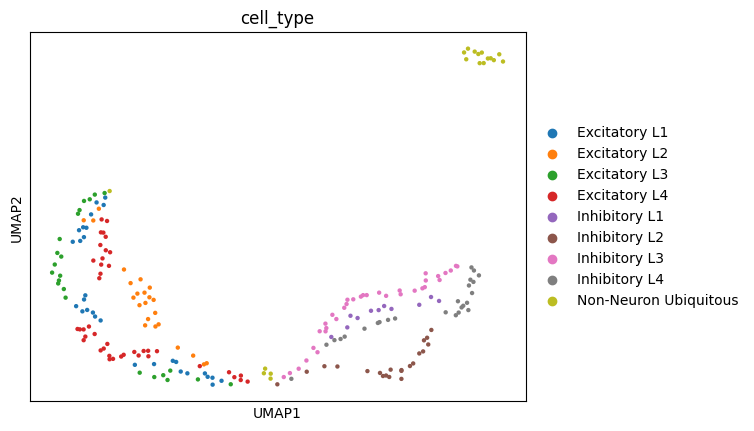

In [384]:
fig, ax = plt.subplots()
sc.pp.neighbors(datasets[0])
sc.tl.umap(datasets[0])
sc.pl.umap(datasets[0], color="cell_type", ax=ax, size=40)

/home/raehashs/miniconda3/envs/batch_correction_distribution/lib/python3.10/site-packages/scanpy/plotting/_tools/scatterplots.py:1217: FutureWarning: The default value of 'ignore' for the `na_action` parameter in pandas.Categorical.map is deprecated and will be changed to 'None' in a future version. Please set na_action to the desired value to avoid seeing this warning
  color_vector = pd.Categorical(values.map(color_map))
/home/raehashs/miniconda3/envs/batch_correction_distribution/lib/python3.10/site-packages/scanpy/plotting/_tools/scatterplots.py:392: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap' will be ignored
  cax = scatter(


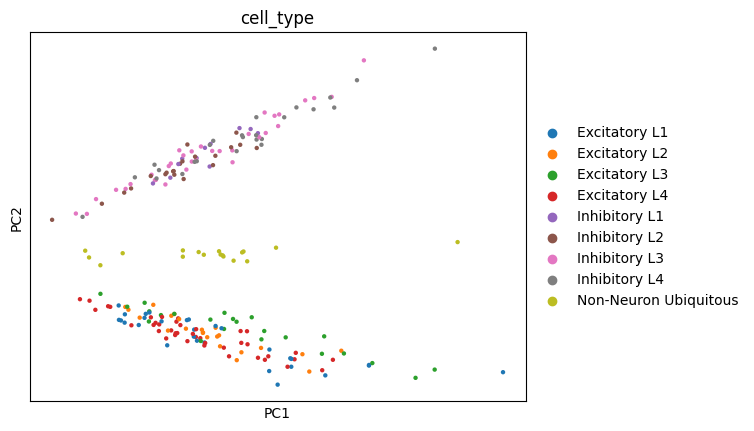

In [385]:
fig, ax = plt.subplots()
sc.tl.pca(datasets[0])
sc.pl.pca(datasets[0], color="cell_type", ax=ax, size=40)

In [386]:
from popari.util import concatenate

         Falling back to preprocessing with `sc.pp.pca` and default params.


/home/raehashs/miniconda3/envs/batch_correction_distribution/lib/python3.10/site-packages/anndata/_core/anndata.py:1756: UserWarning: Observation names are not unique. To make them unique, call `.obs_names_make_unique`.
  utils.warn_names_duplicates("obs")
/home/raehashs/miniconda3/envs/batch_correction_distribution/lib/python3.10/site-packages/anndata/_core/anndata.py:401: FutureWarning: The dtype argument is deprecated and will be removed in late 2024.
  warnings.warn(
/home/raehashs/miniconda3/envs/batch_correction_distribution/lib/python3.10/site-packages/scanpy/plotting/_tools/scatterplots.py:1217: FutureWarning: The default value of 'ignore' for the `na_action` parameter in pandas.Categorical.map is deprecated and will be changed to 'None' in a future version. Please set na_action to the desired value to avoid seeing this warning
  color_vector = pd.Categorical(values.map(color_map))
/home/raehashs/miniconda3/envs/batch_correction_distribution/lib/python3.10/site-packages/scanpy/

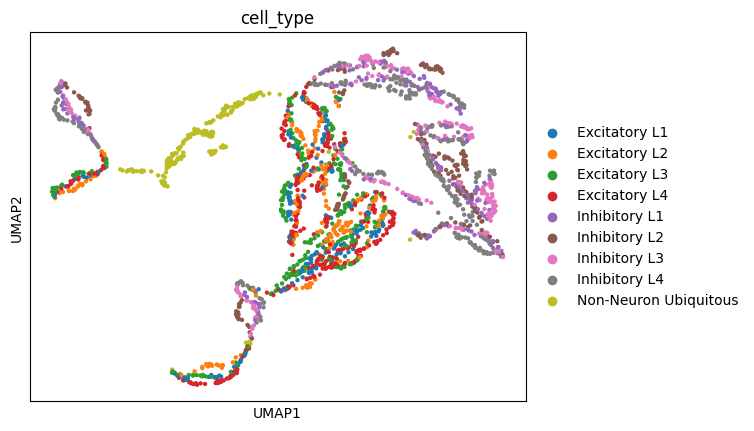

In [387]:
replicate_names, dataset_copies = zip(*multireplicate_dataset.datasets.items())
merged_dataset = concatenate(dataset_copies)                                                                                                                                        
fig, ax = plt.subplots()
sc.pp.neighbors(merged_dataset)
sc.tl.umap(merged_dataset)
sc.pl.umap(merged_dataset, color="cell_type", ax=ax, size=40)

/home/raehashs/miniconda3/envs/batch_correction_distribution/lib/python3.10/site-packages/scanpy/plotting/_tools/scatterplots.py:1217: FutureWarning: The default value of 'ignore' for the `na_action` parameter in pandas.Categorical.map is deprecated and will be changed to 'None' in a future version. Please set na_action to the desired value to avoid seeing this warning
  color_vector = pd.Categorical(values.map(color_map))
/home/raehashs/miniconda3/envs/batch_correction_distribution/lib/python3.10/site-packages/scanpy/plotting/_tools/scatterplots.py:392: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap' will be ignored
  cax = scatter(


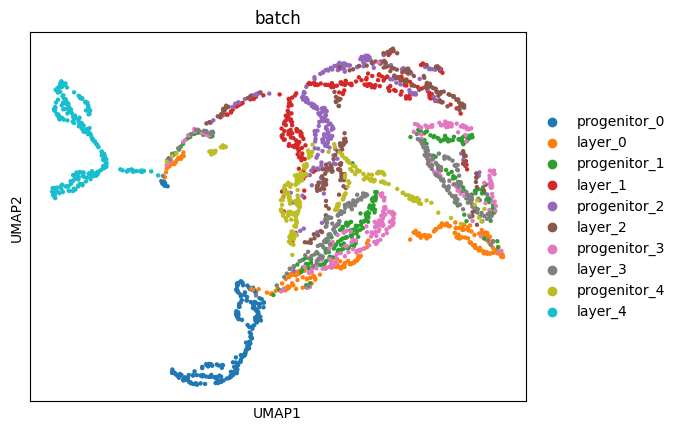

In [388]:
fig, ax = plt.subplots()
sc.pl.umap(merged_dataset, color="batch", ax=ax, size=40)

In [389]:
from popari.util import unconcatenate
datasets = unconcatenate(merged_dataset)
for dataset in datasets:
    print("batch_effect", dataset.uns["batch_effect"][dataset.name])
    print("ground truth", dataset.obsm["ground_truth_X"][0])

batch_effect [0.         0.         4.67985747 0.         0.         0.
 0.         9.62983264 0.         8.41462837 0.        ]
ground truth [ 0.          0.         18.84283101  0.          0.          0.
  0.          9.62983264  0.          8.41462837  0.        ]
batch_effect [0.         0.         0.         0.43820758 0.         0.
 8.83688155 7.62711151 0.         0.         0.        ]
ground truth [ 3.97372693  0.          0.          0.43820758  0.          0.
  8.83688155 22.02981686  0.          0.          0.        ]
batch_effect [0.         0.         0.         7.23880584 0.         0.
 0.         0.         1.43248977 3.45735044 0.        ]
ground truth [3.48665124 0.         0.         7.23880584 0.         0.
 0.         7.22857295 1.43248977 3.45735044 0.        ]
batch_effect [2.38308907 0.         0.         0.06407596 0.         0.
 0.         0.         0.         0.         1.38278772]
ground truth [2.38308907 2.72310959 0.         4.75249411 0.         0.
 0.

In [390]:
save_anndata(f"/home/raehashs/batch_effect_correction/simulated_batch_data/processed_dataset.h5ad", datasets)

/home/raehashs/miniconda3/envs/batch_correction_distribution/lib/python3.10/site-packages/anndata/_core/anndata.py:1756: UserWarning: Observation names are not unique. To make them unique, call `.obs_names_make_unique`.
  utils.warn_names_duplicates("obs")


AnnData object with n_obs × n_vars = 2250 × 100
    obs: 'domain', 'cell_type', 'cell_type_encoded', 'batch'
    uns: 'domain_names', 'simulation_parameters', 'cell_type_definitions', 'batch_effect', 'domain_landmarks', 'ground_truth_M', 'spatial_neighbors', 'neighbors', 'umap', 'cell_type_colors', 'pca', 'adjacency_matrix'
    obsm: 'spatial', 'ground_truth_X', 'adjacency_list', 'X_pca', 'X_umap'
    varm: 'PCs'
    obsp: 'spatial_connectivities', 'spatial_distances', 'adjacency_matrix', 'distances', 'connectivities'

In [393]:
datasets = unconcatenate(merged_dataset)

for dataset in datasets:
    print("batch_effect", dataset.uns["batch_effect"][dataset.name])
    print("ground truth", dataset.obsm["ground_truth_X"].max(axis=0))
    print("ground truth", dataset.obsm["ground_truth_X"].min(axis=0))

batch_effect [0.         0.         4.67985747 0.         0.         0.
 0.         9.62983264 0.         8.41462837 0.        ]
ground truth [ 9.8018514   6.85885019 26.80954452  9.38554258  8.89569016 13.64787538
 14.22327879 23.17051149 11.08991115 22.76717315 10.4503606 ]
ground truth [0.         0.         4.67985747 0.         0.         0.
 0.         9.62983264 0.         8.41462837 0.        ]
batch_effect [0.         0.         0.         0.43820758 0.         0.
 8.83688155 7.62711151 0.         0.         0.        ]
ground truth [ 8.2386135   9.16162671 19.85949298 18.18371086 13.69750565 17.23040097
 23.08026206 22.02981686 11.79625626 15.513982   10.60307401]
ground truth [0.         0.         0.         0.43820758 0.         0.
 8.83688155 7.62711151 0.         0.         0.        ]
batch_effect [0.         0.         0.         7.23880584 0.         0.
 0.         0.         1.43248977 3.45735044 0.        ]
ground truth [ 7.14469399  7.04243032 15.59960279 22.007488

In [399]:
arr = dataset.obsm["ground_truth_X"]
arr_nan = np.where(arr != 0, arr, np.nan)
mean_per_column = np.nanmean(arr_nan, axis=0)
#print(arr_nan)
print(mean_per_column)

[13.98542012  3.65003458  2.57232906  7.33119197  7.64776468  7.62000407
  7.61455886  7.33447363  7.34664019  1.97637629  6.88383099]


In [402]:
for dataset in datasets:
    arr = dataset.obsm["ground_truth_X"] - dataset.uns["batch_effect"][dataset.name]
    arr_nan = np.where(arr != 0, arr, np.nan)
    mean_per_column = np.nanmean(arr_nan, axis=0)
    print("batch_effect", dataset.uns["batch_effect"][dataset.name])
    print("ground_truth", mean_per_column)

batch_effect [0.         0.         4.67985747 0.         0.         0.
 0.         9.62983264 0.         8.41462837 0.        ]
ground_truth [ 3.63409977  3.65200358 11.2499858   7.3816536   6.70121288  7.46718353
  8.36127015  7.62585059  7.52757725  8.27803856  6.99896514]
batch_effect [0.         0.         0.         0.43820758 0.         0.
 8.83688155 7.62711151 0.         0.         0.        ]
ground_truth [ 3.58167721  3.76751999 12.43415541  7.45688068  6.88363035  8.08697765
  7.92789848  8.80770737  6.90041342  7.35311049  7.08892092]
batch_effect [0.         0.         0.         7.23880584 0.         0.
 0.         0.         1.43248977 3.45735044 0.        ]
ground_truth [ 3.67458385  3.67589574 10.84238774  7.08830645  7.57893222  7.77649595
  6.44466779  7.37743518  7.34153681  7.47772873  7.58044823]
batch_effect [2.38308907 0.         0.         0.06407596 0.         0.
 0.         0.         0.         0.         1.38278772]
ground_truth [ 3.66065266  3.82893881 11